## Pengelompokan Tingkat Keparahan Luka Diabetes dari Citra Kaki Menggunakan CNN dan K-Means


## Setup Google Colab

Cell di bawah hanya aktif jika notebook ini dibuka di Google Colab. Jika dijalankan di lokal, cell ini tidak akan melakukan apa-apa.

In [ ]:
import importlib.util

IN_COLAB = importlib.util.find_spec("google.colab") is not None

if IN_COLAB:
    from pathlib import Path

    REPO_URL = "https://github.com/musyaree/fp-kcv.git"
    REPO_DIR = Path("/content/fp-kcv")

    if not REPO_DIR.exists():
        !git clone {REPO_URL} {REPO_DIR}

    %cd {REPO_DIR}/notebook

    raw_dir = REPO_DIR / "data" / "raw"
    if not raw_dir.exists() or not any(raw_dir.iterdir()):
        !python ../download_data.py
else:
    print("Bukan di Colab, lewati setup Colab.")

Bukan di Colab, lewati setup Colab.


## Tahap 0. Setup

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(REPO_ROOT / "src"))

from data_prep import eda, preprocess, split_dataset, subset_dataset

## Tahap 1. Pengumpulan dan Eksplorasi Dataset (EDA)

### 1.1 Mengunduh Dataset & Mengambil Subset

Dataset, Diabetic Foot Ulcer, diunduh terpisah dengan menjalankan `download_data.py`. Kita mengambil subset seimbang, yaitu 240 Abnormal dan 240 Normal, dari folder `Patches/` yang sudah berlabel.

In [2]:
subset_dataset.main(argv=[])

Abnormal: 512 file, 473 unik (39 duplikat dibuang)
Abnormal: 240 gambar disalin ke data\processed\subset\Abnormal
Normal: 543 file, 240 unik (303 duplikat dibuang)
Normal: 240 gambar disalin ke data\processed\subset\Normal

Total: 480 gambar. Manifest disimpan di data\processed\subset\manifest.csv


### 1.2 Eksplorasi Data (EDA)

Cek jumlah gambar per kategori, lihat statistik ukurannya, lalu tampilkan beberapa sampel visual agar variasi data terlihat.

=== EDA Summary — Subset DFU ===

Jumlah gambar per kategori:
  Abnormal: 240
  Normal: 240
  Total: 480

Statistik ukuran gambar:
  Width  : min=220, max=320
  Height : min=220, max=316
  Ukuran unik: [(220, 220), (224, 224), (224, 244), (227, 227), (243, 246), (283, 280), (304, 294), (310, 316), (320, 291)]

Sampel visual disimpan di: outputs\eda_sample_grid.png
Sumber dataset: Kaggle Diabetic Foot Ulcer (DFU) Dataset (Laith Jj)
https://www.kaggle.com/datasets/laithjj/diabetic-foot-ulcer-dfu

Grid sampel disimpan di: outputs\eda_sample_grid.png


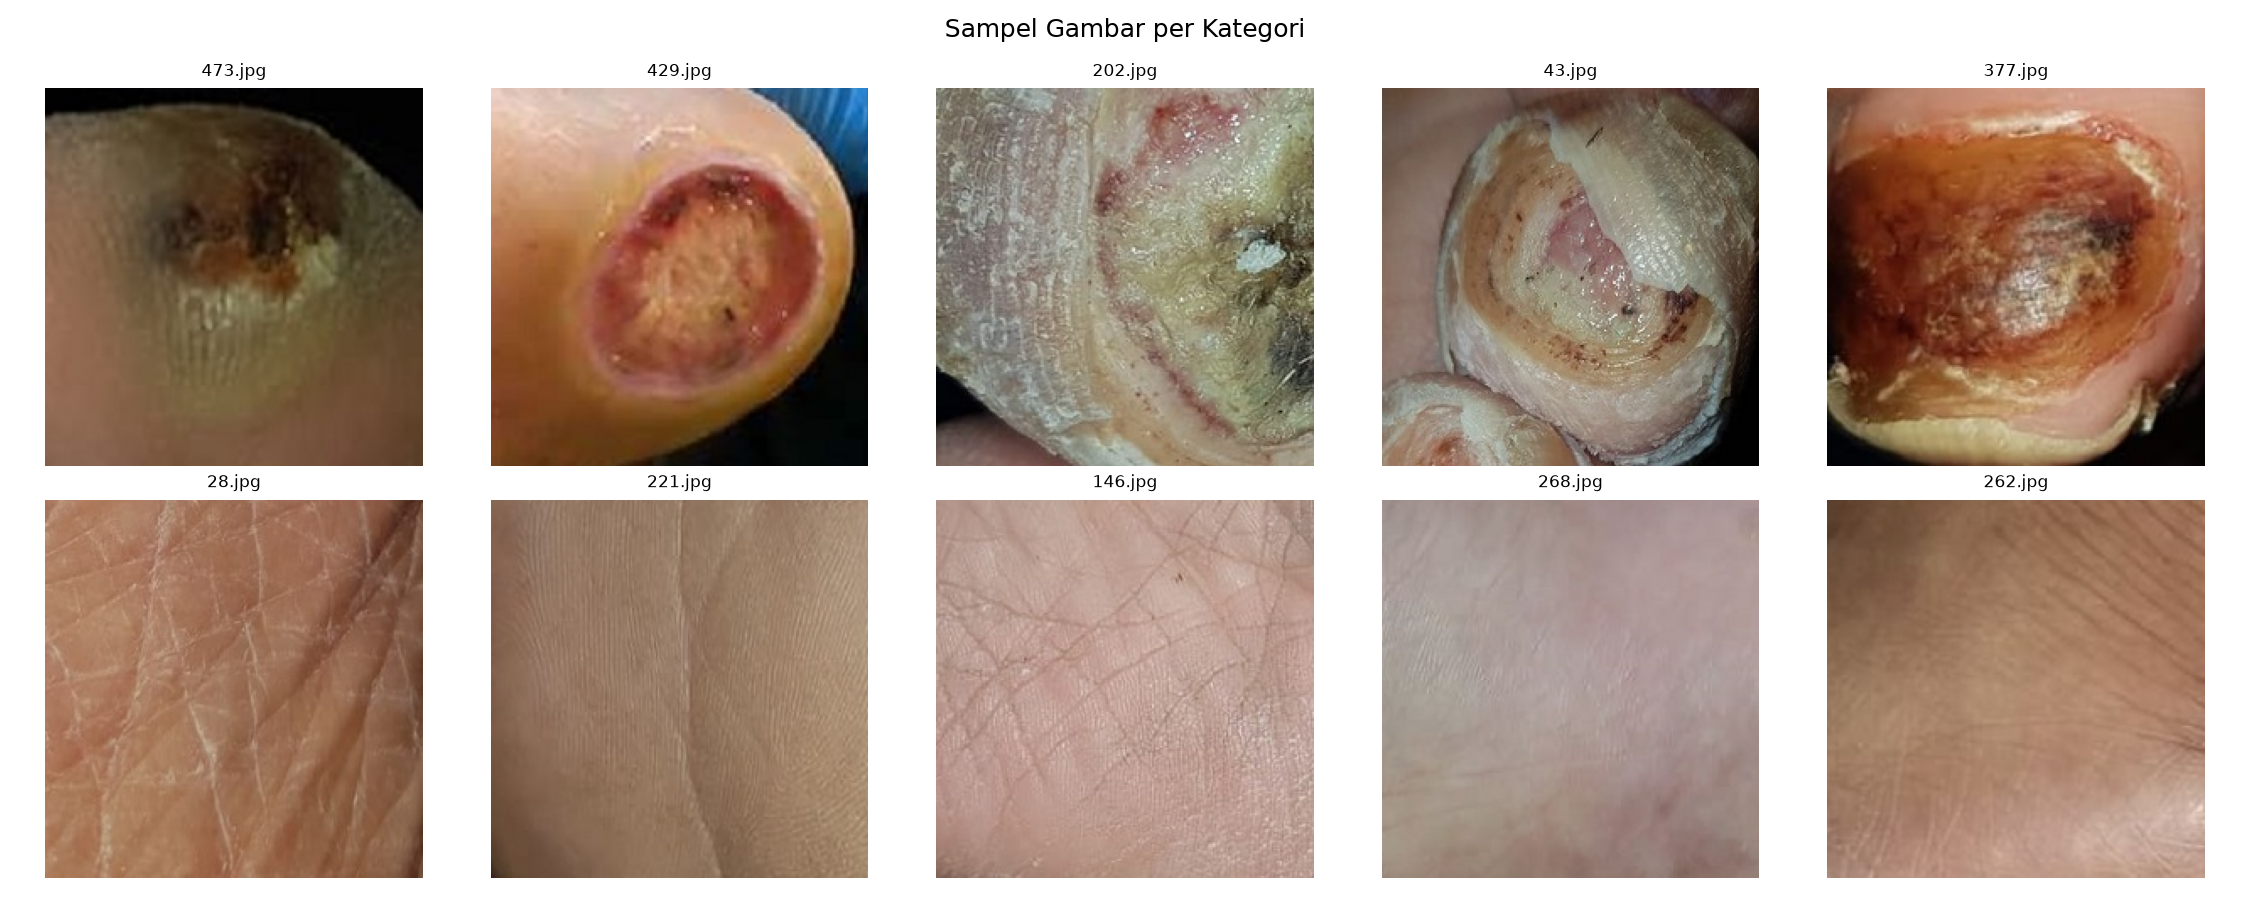

In [3]:
from IPython.display import Image, display

eda.main()
display(Image(filename=str(eda.OUTPUTS_DIR / "eda_sample_grid.png")))

## Tahap 2. Pra-pemrosesan Citra

### 2.1 Standardisasi Ukuran, Format, dan Normalisasi

Pre-Process CNN: resize semua gambar ke ukuran 224x224, lalu normalisasi memakai mean/std ImageNet.
Pre-Process Handcrafted: Konversi ke HSV menggunakan skala 0-1.

In [4]:
preprocess.main()

Selesai preprocessing.


### 2.2 Split Data Latih dan Data Uji

Split 80:20 per kategori, supaya proporsi Normal dan Abnormal tetap seimbang di kedua sisi.

In [5]:
split_dataset.main()

Selesai split data.


In [6]:
import csv

import pandas as pd

with open(split_dataset.MANIFEST_PATH, newline="", encoding="utf-8") as f:
    rows = list(csv.DictReader(f))

df = pd.DataFrame(rows)
pd.crosstab(df["label"], df["split"])

split,test,train
label,,
Abnormal,48,192
Normal,48,192


## Tahap 3. Ekstraksi Fitur

### 3.1 Ekstraksi Fitur CNN

Setiap gambar yang sudah dipreproses diteruskan ke CNN pretrained ResNet50 dengan tanpa layer klasifikasi di ujungnya. Hasil keluaran layer terakhir sebelum klasifikasi berupa vektor 2048 angka per gambar, disebut embedding/ fitur. Vektor ini merepresentasikan pola visual gambar dalam bentuk numerik dan nantinya jadi input untuk clustering K-Means di Tahap 4.

In [7]:
import feature_extraction_cnn

feature_extraction_cnn.main()

Data latih: 384, Data uji: 96
Ekstraksi fitur data latih...
  16/384 gambar diproses
  32/384 gambar diproses
  48/384 gambar diproses
  64/384 gambar diproses
  80/384 gambar diproses
  96/384 gambar diproses
  112/384 gambar diproses
  128/384 gambar diproses
  144/384 gambar diproses
  160/384 gambar diproses
  176/384 gambar diproses
  192/384 gambar diproses
  208/384 gambar diproses
  224/384 gambar diproses
  240/384 gambar diproses
  256/384 gambar diproses
  272/384 gambar diproses
  288/384 gambar diproses
  304/384 gambar diproses
  320/384 gambar diproses
  336/384 gambar diproses
  352/384 gambar diproses
  368/384 gambar diproses
  384/384 gambar diproses
Ekstraksi fitur data uji...
  16/96 gambar diproses
  32/96 gambar diproses
  48/96 gambar diproses
  64/96 gambar diproses
  80/96 gambar diproses
  96/96 gambar diproses
Selesai. X_train: (384, 2048), X_test: (96, 2048)


In [8]:
import numpy as np

X_train = np.load(feature_extraction_cnn.OUTPUTS_DIR / "features_cnn_train.npy")
X_test = np.load(feature_extraction_cnn.OUTPUTS_DIR / "features_cnn_test.npy")
y_train = np.load(feature_extraction_cnn.OUTPUTS_DIR / "labels_train.npy", allow_pickle=True)
y_test = np.load(feature_extraction_cnn.OUTPUTS_DIR / "labels_test.npy", allow_pickle=True)

print("Fitur data latih:", X_train.shape)
print("Fitur data uji:", X_test.shape)
print("Contoh 5 angka pertama dari fitur gambar pertama:", X_train[0][:5])
print("Label unik:", np.unique(y_train))

Fitur data latih: (384, 2048)
Fitur data uji: (96, 2048)
Contoh 5 angka pertama dari fitur gambar pertama: [0.00279746 0.11640824 0.         0.         0.        ]
Label unik: ['Abnormal' 'Normal']


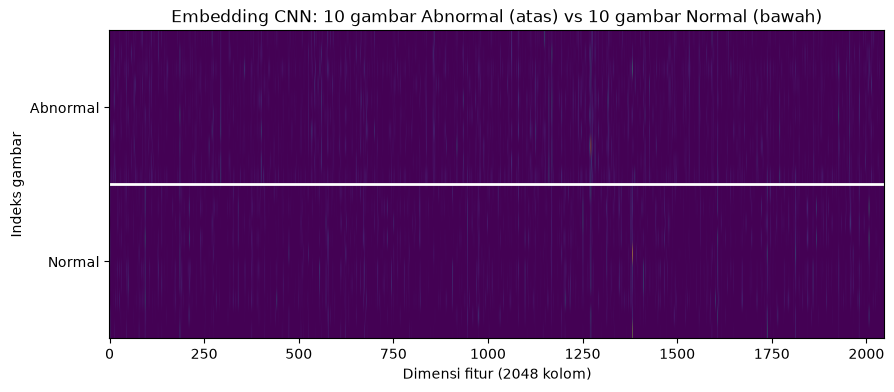

In [9]:
import matplotlib.pyplot as plt

idx_abnormal = np.where(y_train == "Abnormal")[0][:10]
idx_normal = np.where(y_train == "Normal")[0][:10]
idx_sample = np.concatenate([idx_abnormal, idx_normal])

fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(X_train[idx_sample], aspect="auto", cmap="viridis")
ax.axhline(y=9.5, color="white", linewidth=2)
ax.set_title("Embedding CNN: 10 gambar Abnormal (atas) vs 10 gambar Normal (bawah)")
ax.set_xlabel("Dimensi fitur (2048 kolom)")
ax.set_ylabel("Indeks gambar")
ax.set_yticks([4.5, 14.5])
ax.set_yticklabels(["Abnormal", "Normal"])
plt.show()

### 3.2 Ekstraksi Fitur Handcrafted (Warna)

Sebagai pembanding CNN embedding, dihitung fitur warna sederhana dari citra HSV, yaitu rata-rata (mean), standar deviasi, dan skewness tiap channel (H, S, V). Ketiga momen statistik ini disebut color moments. Fitur ini jauh lebih sederhana dari embedding CNN, tujuannya untuk melihat apakah fitur dari deep learning benar-benar memberi nilai tambah dibanding fitur warna biasa.

In [10]:
import feature_extraction_handcrafted

feature_extraction_handcrafted.main()

Data latih: 384, Data uji: 96
Ekstraksi fitur handcrafted data latih...
  50/384 gambar diproses
  100/384 gambar diproses
  150/384 gambar diproses
  200/384 gambar diproses
  250/384 gambar diproses
  300/384 gambar diproses
  350/384 gambar diproses
  384/384 gambar diproses
Ekstraksi fitur handcrafted data uji...
  50/96 gambar diproses
  96/96 gambar diproses
Selesai. X_train: (384, 9), X_test: (96, 9)


In [11]:
X_train_hc = np.load(feature_extraction_handcrafted.OUTPUTS_DIR / "features_handcrafted_train.npy")
X_test_hc = np.load(feature_extraction_handcrafted.OUTPUTS_DIR / "features_handcrafted_test.npy")

print("Fitur handcrafted data latih:", X_train_hc.shape)
print("Fitur handcrafted data uji:", X_test_hc.shape)

kolom = ["mean_H", "std_H", "skew_H", "mean_S", "std_S", "skew_S", "mean_V", "std_V", "skew_V"]
pd.DataFrame(X_train_hc[:5], columns=kolom)

Fitur handcrafted data latih: (384, 9)
Fitur handcrafted data uji: (96, 9)


,mean_H,std_H,skew_H,mean_S,std_S,skew_S,mean_V,std_V,skew_V
0,0.085336,0.038247,15.949054,0.610659,0.121624,0.297118,0.697116,0.172069,-1.757630
1,0.192471,0.297118,2.258852,0.350454,0.132420,1.457768,0.828843,0.096500,-1.752065
2,0.062503,0.061741,13.253073,0.453882,0.143112,0.910084,0.561573,0.167378,-1.088852
3,0.323181,0.426587,0.881925,0.446723,0.149535,0.420270,0.461708,0.210819,0.888673
4,0.406918,0.431940,0.429468,0.489816,0.235502,-0.246705,0.547516,0.142060,0.587489


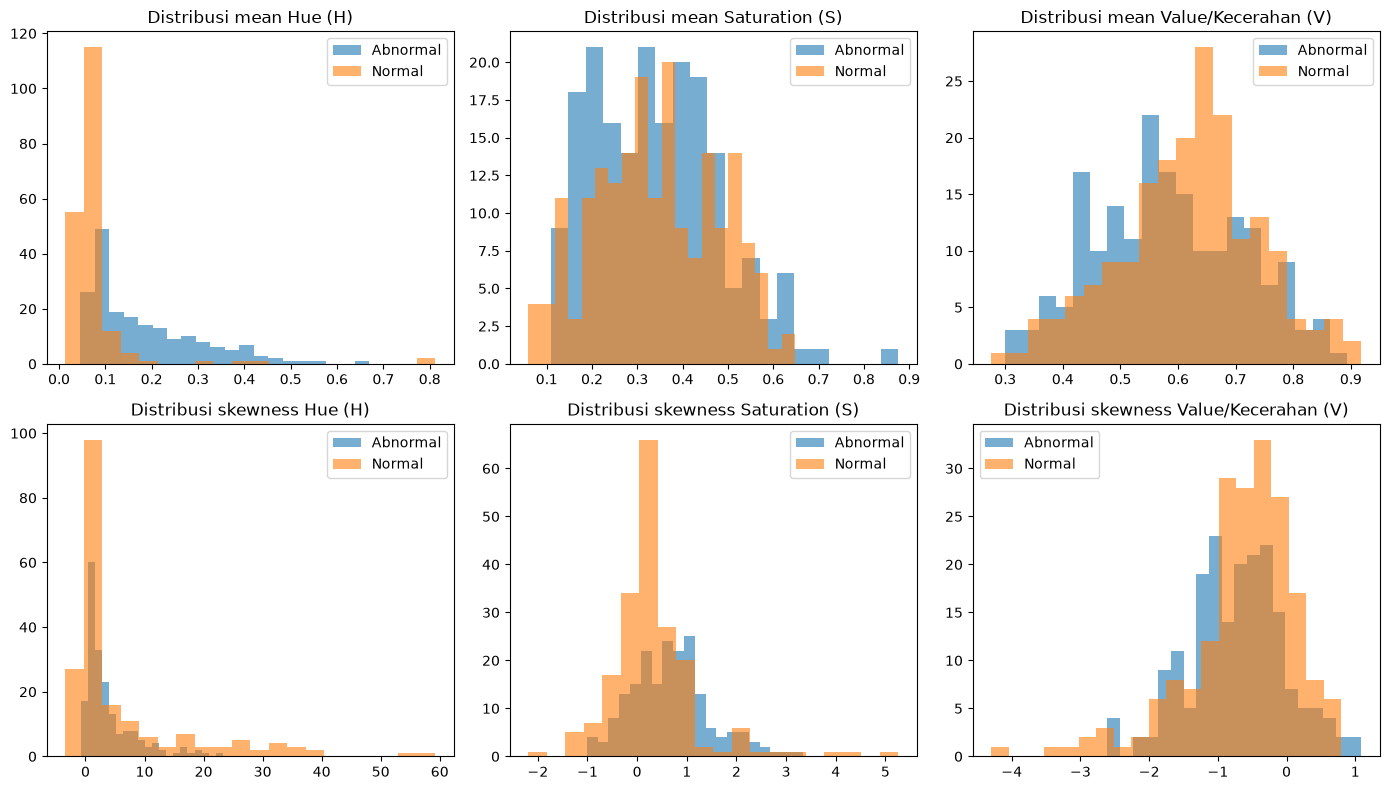

In [12]:
# bandingkan distribusi mean dan skewness warna abnormal vs normal
y_train_arr = np.array([r["label"] for r in feature_extraction_handcrafted.load_manifest() if r["split"] == "train"])

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
nama_channel = ["Hue (H)", "Saturation (S)", "Value/Kecerahan (V)"]

for i in range(3):
    idx_mean = i * 3      # kolom mean tiap channel ada di index 0, 3, 6
    idx_skew = i * 3 + 2  # kolom skew tiap channel ada di index 2, 5, 8

    axes[0, i].hist(X_train_hc[y_train_arr == "Abnormal", idx_mean], bins=20, alpha=0.6, label="Abnormal")
    axes[0, i].hist(X_train_hc[y_train_arr == "Normal", idx_mean], bins=20, alpha=0.6, label="Normal")
    axes[0, i].set_title(f"Distribusi mean {nama_channel[i]}")
    axes[0, i].legend()

    axes[1, i].hist(X_train_hc[y_train_arr == "Abnormal", idx_skew], bins=20, alpha=0.6, label="Abnormal")
    axes[1, i].hist(X_train_hc[y_train_arr == "Normal", idx_skew], bins=20, alpha=0.6, label="Normal")
    axes[1, i].set_title(f"Distribusi skewness {nama_channel[i]}")
    axes[1, i].legend()

plt.tight_layout()
plt.show()

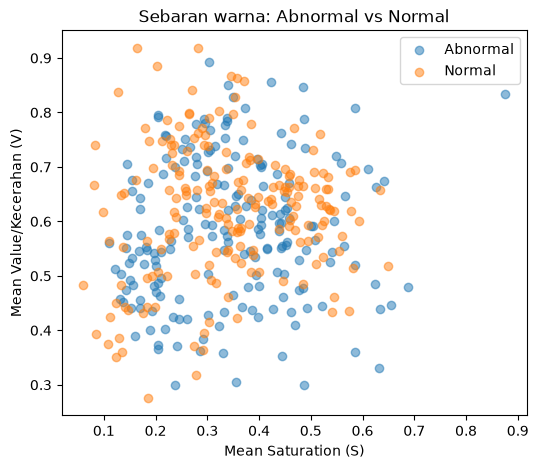

In [13]:
# scatter saturasi vs kecerahan, per kelas
plt.figure(figsize=(6, 5))
plt.scatter(X_train_hc[y_train_arr == "Abnormal", 3], X_train_hc[y_train_arr == "Abnormal", 6], alpha=0.5, label="Abnormal")
plt.scatter(X_train_hc[y_train_arr == "Normal", 3], X_train_hc[y_train_arr == "Normal", 6], alpha=0.5, label="Normal")
plt.xlabel("Mean Saturation (S)")
plt.ylabel("Mean Value/Kecerahan (V)")
plt.title("Sebaran warna: Abnormal vs Normal")
plt.legend()
plt.show()

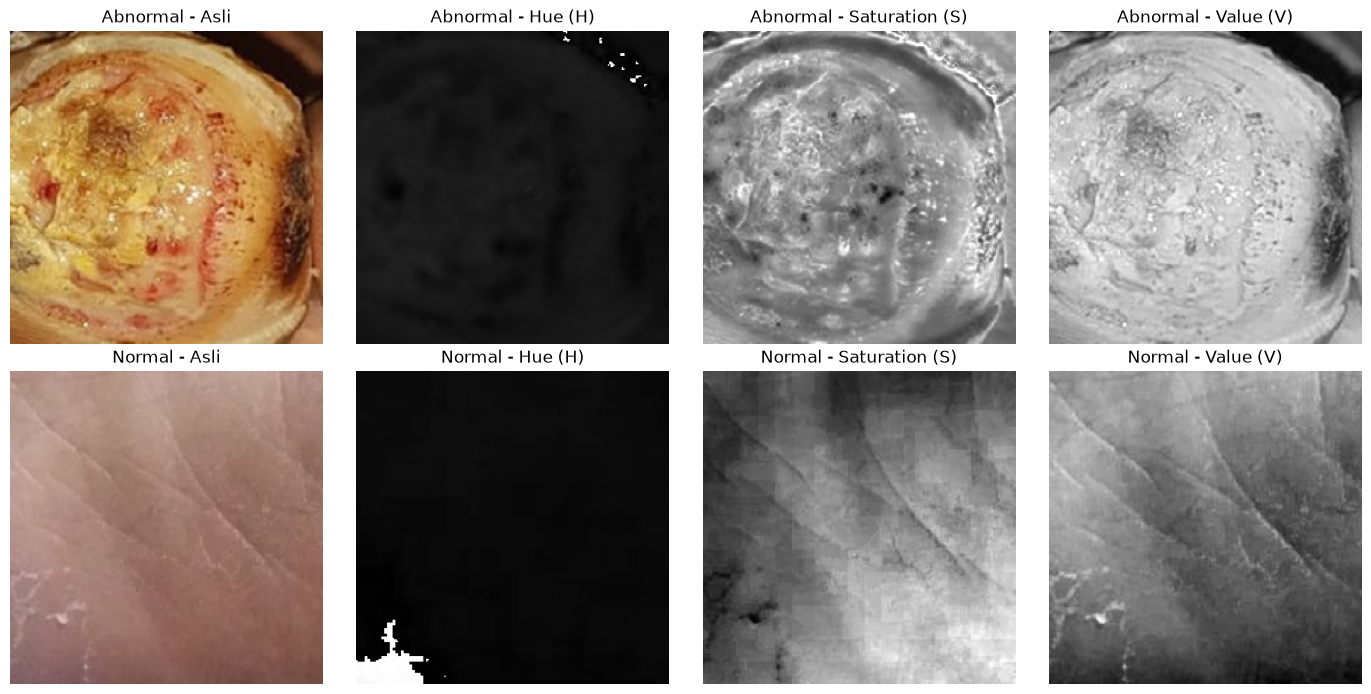

In [14]:
# bandingkan gambar asli dengan tiap channel HSV
from PIL import Image

manifest_rows = feature_extraction_handcrafted.load_manifest()
contoh_abnormal = next(r for r in manifest_rows if r["label"] == "Abnormal" and r["split"] == "train")
contoh_normal = next(r for r in manifest_rows if r["label"] == "Normal" and r["split"] == "train")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
nama_channel = ["Asli", "Hue (H)", "Saturation (S)", "Value (V)"]

for i, contoh in enumerate([contoh_abnormal, contoh_normal]):
    img_asli = Image.open(feature_extraction_handcrafted.SUBSET_DIR / contoh["label"] / contoh["filename"])
    arr_hsv = np.load(feature_extraction_handcrafted.PREPROCESSED_DIR / "hsv_normalized" / contoh["label"] / Path(contoh["filename"]).with_suffix(".npy"))

    axes[i, 0].imshow(img_asli)
    axes[i, 0].set_title(f"{contoh['label']} - {nama_channel[0]}")
    axes[i, 0].axis("off")

    for c in range(3):
        axes[i, c + 1].imshow(arr_hsv[:, :, c], cmap="gray")
        axes[i, c + 1].set_title(f"{contoh['label']} - {nama_channel[c + 1]}")
        axes[i, c + 1].axis("off")

plt.tight_layout()
plt.show()

## Tahap 5. Skenario Eksperimen 1: Uji Jumlah Cluster (K)

Menjawab pertanyaan: berapa jumlah kelompok yang paling optimal untuk data ini, berdasarkan bukti statistik.

### 5.1 Menyiapkan Fungsi Clustering Reusable

Fungsi ini akan dipakai ulang di Skenario 2 dan 3, sehingga kode tidak perlu ditulis berkali-kali.

In [15]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
from sklearn.metrics import silhouette_score, silhouette_samples

RANDOM_STATE = 42
N_INIT = 10


def run_kmeans_experiment(X_train, X_test, k, random_state=RANDOM_STATE, n_init=N_INIT):
    """
    Menjalankan K-Means untuk satu nilai k: di-fit pada X_train, dievaluasi
    pada X_train maupun X_test. Reusable untuk Skenario 2 (jenis fitur) dan
    Skenario 3 (dengan/tanpa PCA) -- tinggal ganti X_train/X_test yang dikirim.
    """
    model = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
    labels_train = model.fit_predict(X_train)
    labels_test = model.predict(X_test)

    inertia_train = model.inertia_
    silhouette_train = silhouette_score(X_train, labels_train) if k > 1 else float("nan")
    silhouette_test = silhouette_score(X_test, labels_test) if k > 1 else float("nan")

    return {
        "model": model,
        "k": k,
        "inertia_train": inertia_train,
        "labels_train": labels_train,
        "labels_test": labels_test,
        "silhouette_train": silhouette_train,
        "silhouette_test": silhouette_test,
    }

### 5.2 Menjalankan K-Means dengan Berbagai Nilai K

Menguji beberapa kemungkinan jumlah cluster untuk melihat mana yang paling koheren.

#### 5.2.1 Menyamakan Skala Fitur Embedding CNN

Membandingkan beberapa metode normalisasi menggunakan data latih saja (agar tidak bocor ke data uji), lalu memilih yang menghasilkan cluster paling koheren (Silhouette Score tertinggi).

In [16]:
scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "L2Normalizer": Normalizer(norm="l2"),
}

hasil_normalisasi = []
scaler_terfit = {}

for nama, scaler in scalers.items():
    X_train_scaled = scaler.fit_transform(X_train)
    scaler_terfit[nama] = scaler

    km_cek = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=N_INIT)
    labels_cek = km_cek.fit_predict(X_train_scaled)
    skor = silhouette_score(X_train_scaled, labels_cek)

    hasil_normalisasi.append({"metode_normalisasi": nama, "silhouette_score": skor})

df_normalisasi = pd.DataFrame(hasil_normalisasi).sort_values(
    "silhouette_score", ascending=False
).reset_index(drop=True)
print(df_normalisasi.to_string(index=False))

metode_terbaik = df_normalisasi.iloc[0]["metode_normalisasi"]
scaler_terbaik = scaler_terfit[metode_terbaik]

X_train_scaled = scaler_terbaik.transform(X_train)
X_test_scaled = scaler_terbaik.transform(X_test)

print(f"\nMetode normalisasi terpilih: {metode_terbaik}")

metode_normalisasi  silhouette_score
      L2Normalizer          0.143155
      MinMaxScaler          0.078379
    StandardScaler          0.050144

Metode normalisasi terpilih: L2Normalizer


#### 5.2.2 - 5.2.4 Menjalankan K-Means K=2 s.d. 10, Elbow Method, dan Silhouette Score

Fokus pembahasan pada K = 2, 3, dan 4.

In [17]:
K_RANGE = list(range(2, 11))
K_FOKUS = [2, 3, 4]

baris_ringkasan = []
eksperimen = {}

for k in K_RANGE:
    hasil = run_kmeans_experiment(X_train_scaled, X_test_scaled, k)
    eksperimen[k] = hasil
    baris_ringkasan.append({
        "k": k,
        "wcss_train": hasil["inertia_train"],
        "silhouette_train": hasil["silhouette_train"],
        "silhouette_test": hasil["silhouette_test"],
    })
    print(f"K={k:>2} | WCSS(train)={hasil['inertia_train']:.2f} "
          f"| Silhouette(train)={hasil['silhouette_train']:.4f} "
          f"| Silhouette(test)={hasil['silhouette_test']:.4f}")

df_ringkasan = pd.DataFrame(baris_ringkasan)
df_ringkasan

K= 2 | WCSS(train)=195.35 | Silhouette(train)=0.1721 | Silhouette(test)=0.1963
K= 3 | WCSS(train)=180.38 | Silhouette(train)=0.1432 | Silhouette(test)=0.1524
K= 4 | WCSS(train)=173.43 | Silhouette(train)=0.0956 | Silhouette(test)=0.0939
K= 5 | WCSS(train)=168.12 | Silhouette(train)=0.0892 | Silhouette(test)=0.0794
K= 6 | WCSS(train)=163.25 | Silhouette(train)=0.0911 | Silhouette(test)=0.0783
K= 7 | WCSS(train)=159.24 | Silhouette(train)=0.0884 | Silhouette(test)=0.0666
K= 8 | WCSS(train)=156.24 | Silhouette(train)=0.0880 | Silhouette(test)=0.0606
K= 9 | WCSS(train)=154.16 | Silhouette(train)=0.0841 | Silhouette(test)=0.0655
K=10 | WCSS(train)=152.25 | Silhouette(train)=0.0625 | Silhouette(test)=0.0438


,k,wcss_train,silhouette_train,silhouette_test
0,2,195.351257,0.172056,0.196346
1,3,180.375946,0.143155,0.152426
2,4,173.432755,0.095602,0.093913
3,5,168.116470,0.089219,0.079431
4,6,163.254852,0.091112,0.078300
5,7,159.235291,0.088383,0.066609
6,8,156.239502,0.088036,0.060611
7,9,154.160339,0.084142,0.065477
8,10,152.250183,0.062510,0.043770


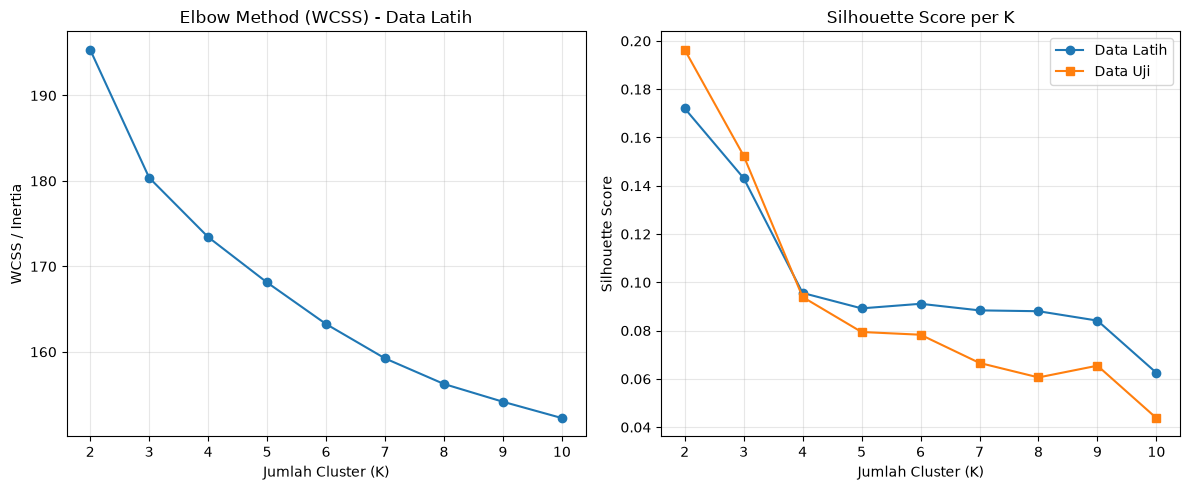

Grafik disimpan di: C:\Users\Raihan Naufal R\OneDrive\Documents\fp-kcv-new\outputs\skenario1_elbow_silhouette.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(df_ringkasan["k"], df_ringkasan["wcss_train"], marker="o")
axes[0].set_title("Elbow Method (WCSS) - Data Latih")
axes[0].set_xlabel("Jumlah Cluster (K)")
axes[0].set_ylabel("WCSS / Inertia")
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_ringkasan["k"], df_ringkasan["silhouette_train"], marker="o", label="Data Latih")
axes[1].plot(df_ringkasan["k"], df_ringkasan["silhouette_test"], marker="s", label="Data Uji")
axes[1].set_title("Silhouette Score per K")
axes[1].set_xlabel("Jumlah Cluster (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plot_path = feature_extraction_cnn.OUTPUTS_DIR / "skenario1_elbow_silhouette.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Grafik disimpan di: {plot_path}")

### 5.3 Menentukan K Optimal

Hasil tahap ini menjadi acuan K yang dipakai di Skenario 2 dan 3.

#### 5.3.1 Tentukan K dari Kurva Data Latih

In [19]:
df_fokus = df_ringkasan[df_ringkasan["k"].isin(K_FOKUS)]
print(df_fokus.to_string(index=False))

k_terbaik = int(df_ringkasan.loc[df_ringkasan["silhouette_train"].idxmax(), "k"])
print(f"\nRekomendasi awal K optimal (Silhouette tertinggi, data latih): K={k_terbaik}")
print("Cek ulang secara visual dari kurva Elbow di atas, lalu konfirmasi dengan 5.3.2 di bawah.")

 k  wcss_train  silhouette_train  silhouette_test
 2  195.351257          0.172056         0.196346
 3  180.375946          0.143155         0.152426
 4  173.432755          0.095602         0.093913

Rekomendasi awal K optimal (Silhouette tertinggi, data latih): K=2
Cek ulang secara visual dari kurva Elbow di atas, lalu konfirmasi dengan 5.3.2 di bawah.


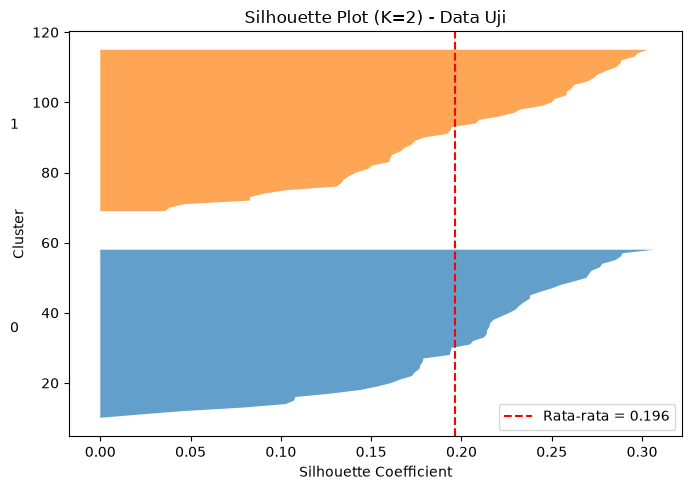

In [20]:
def plot_silhouette_detail(X, labels, k):
    sample_scores = silhouette_samples(X, labels)
    skor_rata2 = silhouette_score(X, labels)

    fig, ax = plt.subplots(figsize=(7, 5))
    y_lower = 10
    for i in range(k):
        skor_cluster = sample_scores[labels == i]
        skor_cluster.sort()
        ukuran = skor_cluster.shape[0]
        y_upper = y_lower + ukuran
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, skor_cluster, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * ukuran, str(i))
        y_lower = y_upper + 10

    ax.axvline(x=skor_rata2, color="red", linestyle="--", label=f"Rata-rata = {skor_rata2:.3f}")
    ax.set_title(f"Silhouette Plot (K={k}) - Data Uji")
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_ylabel("Cluster")
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_silhouette_detail(X_test_scaled, eksperimen[k_terbaik]["labels_test"], k_terbaik)

#### 5.3.2 Bandingkan Isi Setiap Cluster dengan Label Asli

Dibandingkan untuk K = 2, 3, dan 4 sekaligus, agar terlihat mana yang paling sesuai dengan kategori Abnormal/Normal yang sebenarnya.

In [21]:
for k in K_FOKUS:
    labels_test_k = eksperimen[k]["labels_test"]
    crosstab = pd.crosstab(labels_test_k, y_test)
    crosstab_persen = pd.crosstab(labels_test_k, y_test, normalize="index").round(3) * 100

    print(f"\n=== K={k}: Jumlah sampel per cluster x label asli ===")
    print(crosstab.to_string())
    print(f"\n=== K={k}: Proporsi (%) per cluster ===")
    print(crosstab_persen.to_string())


=== K=2: Jumlah sampel per cluster x label asli ===
col_0  Abnormal  Normal
row_0                  
0            46       3
1             2      45

=== K=2: Proporsi (%) per cluster ===
col_0  Abnormal  Normal
row_0                  
0          93.9     6.1
1           4.3    95.7

=== K=3: Jumlah sampel per cluster x label asli ===
col_0  Abnormal  Normal
row_0                  
0             0      27
1            46       2
2             2      19

=== K=3: Proporsi (%) per cluster ===
col_0  Abnormal  Normal
row_0                  
0           0.0   100.0
1          95.8     4.2
2           9.5    90.5

=== K=4: Jumlah sampel per cluster x label asli ===
col_0  Abnormal  Normal
row_0                  
0            11       4
1             2      20
2            35       0
3             0      24

=== K=4: Proporsi (%) per cluster ===
col_0  Abnormal  Normal
row_0                  
0          73.3    26.7
1           9.1    90.9
2         100.0     0.0
3           0.0   100.0


#### 5.3.3 Catat K Terbaik Beserta Grafik Pendukung untuk Slide

In [22]:
import json

laporan = {
    "k_optimal_terpilih": k_terbaik,
    "metode_normalisasi_terpilih": metode_terbaik,
    "catatan": (
        "K optimal dipilih berdasarkan kurva Silhouette Score & Elbow Method "
        "pada data latih, dikonfirmasi dengan interpretasi label asli pada "
        "data uji. Nilai ini menjadi acuan K untuk Skenario 2 dan Skenario 3."
    ),
    "ringkasan_metrik": df_ringkasan.to_dict(orient="records"),
}

laporan_path = feature_extraction_cnn.OUTPUTS_DIR / "skenario1_hasil_uji_k.json"
with open(laporan_path, "w", encoding="utf-8") as f:
    json.dump(laporan, f, indent=2, ensure_ascii=False)

ringkasan_path = feature_extraction_cnn.OUTPUTS_DIR / "skenario1_ringkasan_metrik.csv"
df_ringkasan.to_csv(ringkasan_path, index=False)

print(f"K optimal terpilih: {k_terbaik}")
print(f"Hasil disimpan di:\n  {laporan_path}\n  {ringkasan_path}")

K optimal terpilih: 2
Hasil disimpan di:
  C:\Users\Raihan Naufal R\OneDrive\Documents\fp-kcv-new\outputs\skenario1_hasil_uji_k.json
  C:\Users\Raihan Naufal R\OneDrive\Documents\fp-kcv-new\outputs\skenario1_ringkasan_metrik.csv


## Tahap 6. Skenario Eksperimen 2 & 3: Perbandingan Fitur dan PCA

Menjawab dua pertanyaan desain sekaligus: fitur apa yang paling representatif, dan apakah reduksi dimensi (PCA) membantu.

### 6.1 Skenario 2: Perbandingan Jenis Fitur

Membandingkan fitur CNN embedding vs fitur handcrafted, menggunakan K terbaik dari Skenario 1.

#### 6.1.1 Jalankan K-Means (K Terbaik) Menggunakan Fitur Embedding CNN

In [23]:
# Sudah dijalankan di Tahap 5 (5.2.2-5.2.4) untuk semua K, tinggal ambil hasil pada K terbaik
hasil_cnn_final = eksperimen[k_terbaik]

print(f"=== K-Means (K={k_terbaik}) - Fitur Embedding CNN ===")
print(f"Silhouette (train): {hasil_cnn_final['silhouette_train']:.4f}")
print(f"Silhouette (test):  {hasil_cnn_final['silhouette_test']:.4f}")

=== K-Means (K=2) - Fitur Embedding CNN ===
Silhouette (train): 0.1721
Silhouette (test):  0.1963


#### 6.1.2 Jalankan K-Means (K Terbaik) Menggunakan Fitur Handcrafted

In [24]:
# Fitur handcrafted disamakan skalanya memakai metode yang sama seperti fitur CNN (lihat 5.2.1)
ScalerTerbaikClass = type(scaler_terbaik)
scaler_hc = ScalerTerbaikClass()

X_train_hc_scaled = scaler_hc.fit_transform(X_train_hc)
X_test_hc_scaled = scaler_hc.transform(X_test_hc)

hasil_hc_final = run_kmeans_experiment(X_train_hc_scaled, X_test_hc_scaled, k_terbaik)

print(f"=== K-Means (K={k_terbaik}) - Fitur Handcrafted (Warna) ===")
print(f"Silhouette (train): {hasil_hc_final['silhouette_train']:.4f}")
print(f"Silhouette (test):  {hasil_hc_final['silhouette_test']:.4f}")

=== K-Means (K=2) - Fitur Handcrafted (Warna) ===
Silhouette (train): 0.4479
Silhouette (test):  0.4178


#### 6.1.3 Bandingkan Silhouette Score dan Visual Isi Cluster dari Kedua Hasil

        jenis_fitur  n_fitur  silhouette_train  silhouette_test
      CNN Embedding     2048          0.172056         0.196346
Handcrafted (Warna)        9          0.447946         0.417789


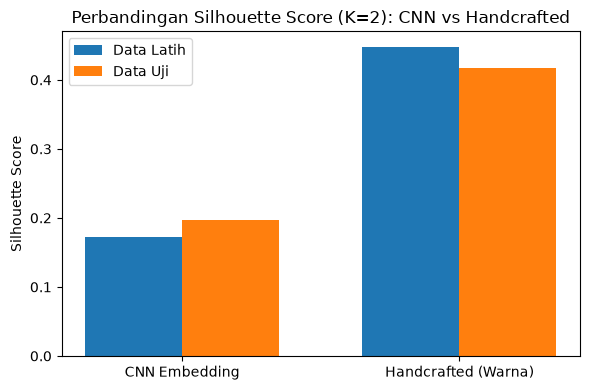

Grafik disimpan di: C:\Users\Raihan Naufal R\OneDrive\Documents\fp-kcv-new\outputs\skenario2_perbandingan_silhouette.png


In [25]:
df_perbandingan_fitur = pd.DataFrame([
    {
        "jenis_fitur": "CNN Embedding",
        "n_fitur": X_train_scaled.shape[1],
        "silhouette_train": hasil_cnn_final["silhouette_train"],
        "silhouette_test": hasil_cnn_final["silhouette_test"],
    },
    {
        "jenis_fitur": "Handcrafted (Warna)",
        "n_fitur": X_train_hc_scaled.shape[1],
        "silhouette_train": hasil_hc_final["silhouette_train"],
        "silhouette_test": hasil_hc_final["silhouette_test"],
    },
])
print(df_perbandingan_fitur.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
x_pos = np.arange(len(df_perbandingan_fitur))
lebar = 0.35
ax.bar(x_pos - lebar / 2, df_perbandingan_fitur["silhouette_train"], lebar, label="Data Latih")
ax.bar(x_pos + lebar / 2, df_perbandingan_fitur["silhouette_test"], lebar, label="Data Uji")
ax.set_xticks(x_pos)
ax.set_xticklabels(df_perbandingan_fitur["jenis_fitur"])
ax.set_ylabel("Silhouette Score")
ax.set_title(f"Perbandingan Silhouette Score (K={k_terbaik}): CNN vs Handcrafted")
ax.legend()
plt.tight_layout()

plot_path_fitur = feature_extraction_cnn.OUTPUTS_DIR / "skenario2_perbandingan_silhouette.png"
plt.savefig(plot_path_fitur, dpi=150, bbox_inches="tight")
plt.show()

print(f"Grafik disimpan di: {plot_path_fitur}")

In [26]:
print(f"=== Isi Cluster vs Label Asli - Fitur CNN Embedding (K={k_terbaik}) ===")
crosstab_cnn = pd.crosstab(hasil_cnn_final["labels_test"], y_test)
print(crosstab_cnn.to_string())

print(f"\n=== Isi Cluster vs Label Asli - Fitur Handcrafted (K={k_terbaik}) ===")
crosstab_hc = pd.crosstab(hasil_hc_final["labels_test"], y_test)
print(crosstab_hc.to_string())

=== Isi Cluster vs Label Asli - Fitur CNN Embedding (K=2) ===
col_0  Abnormal  Normal
row_0                  
0            46       3
1             2      45

=== Isi Cluster vs Label Asli - Fitur Handcrafted (K=2) ===
col_0  Abnormal  Normal
row_0                  
0            41      23
1             7      25


Visualisasi sebaran cluster dalam 2 dimensi (memakai PCA **hanya untuk keperluan plot**, bukan bagian dari eksperimen PCA di Skenario 3 yang akan dibahas terpisah).

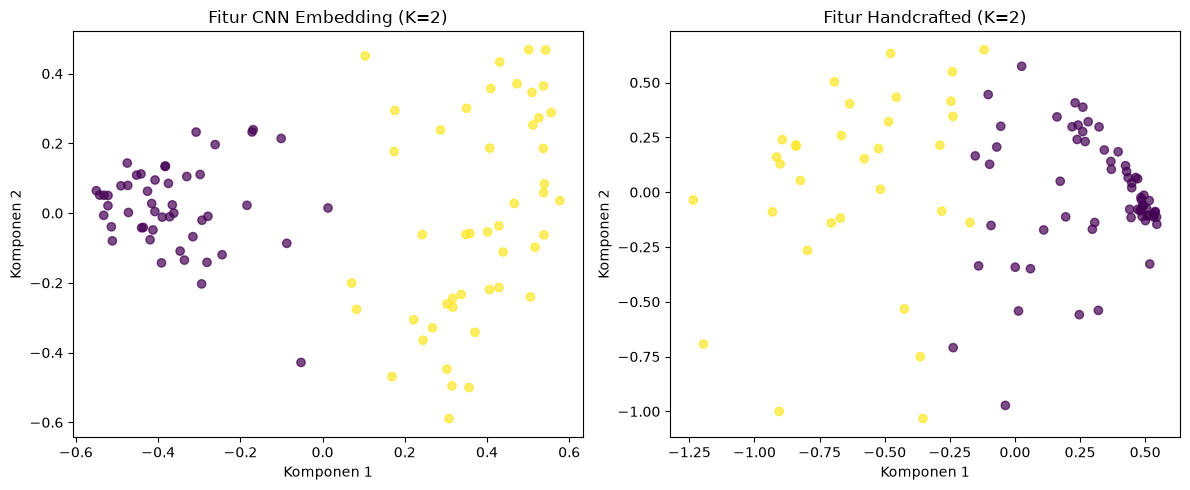

Grafik disimpan di: C:\Users\Raihan Naufal R\OneDrive\Documents\fp-kcv-new\outputs\skenario2_visual_cluster_2d.png


In [27]:
from sklearn.decomposition import PCA


def scatter_cluster_2d(X, labels, ax, judul):
    pca_viz = PCA(n_components=2, random_state=RANDOM_STATE)
    X_2d = pca_viz.fit_transform(X)
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="viridis", alpha=0.7)
    ax.set_title(judul)
    ax.set_xlabel("Komponen 1")
    ax.set_ylabel("Komponen 2")


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
scatter_cluster_2d(X_test_scaled, hasil_cnn_final["labels_test"], axes[0],
                   f"Fitur CNN Embedding (K={k_terbaik})")
scatter_cluster_2d(X_test_hc_scaled, hasil_hc_final["labels_test"], axes[1],
                   f"Fitur Handcrafted (K={k_terbaik})")
plt.tight_layout()

plot_path_visual = feature_extraction_cnn.OUTPUTS_DIR / "skenario2_visual_cluster_2d.png"
plt.savefig(plot_path_visual, dpi=150, bbox_inches="tight")
plt.show()

print(f"Grafik disimpan di: {plot_path_visual}")

In [28]:
laporan_skenario2 = {
    "k_digunakan": k_terbaik,
    "perbandingan_fitur": df_perbandingan_fitur.to_dict(orient="records"),
    "catatan": (
        "Fitur dengan Silhouette Score lebih tinggi pada data uji dianggap "
        "lebih representatif untuk clustering. Lihat juga crosstab isi cluster "
        "vs label asli untuk menilai keterpisahan Abnormal/Normal secara kualitatif."
    ),
}

laporan_skenario2_path = feature_extraction_cnn.OUTPUTS_DIR / "skenario2_hasil_perbandingan_fitur.json"
with open(laporan_skenario2_path, "w", encoding="utf-8") as f:
    json.dump(laporan_skenario2, f, indent=2, ensure_ascii=False)

print(f"Hasil Skenario 2 disimpan di: {laporan_skenario2_path}")

Hasil Skenario 2 disimpan di: C:\Users\Raihan Naufal R\OneDrive\Documents\fp-kcv-new\outputs\skenario2_hasil_perbandingan_fitur.json
